In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("house_prices.csv")

In [28]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [29]:
data.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [32]:
data.dropna(inplace=True)

In [33]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [34]:
data.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [8]:
# We'll split the data into two: one for training and one for testing
from sklearn.model_selection import train_test_split

x = data.drop(["median_house_value"], axis=1)
y = data["median_house_value"]

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [10]:
train_data = x_train.join(y_train)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

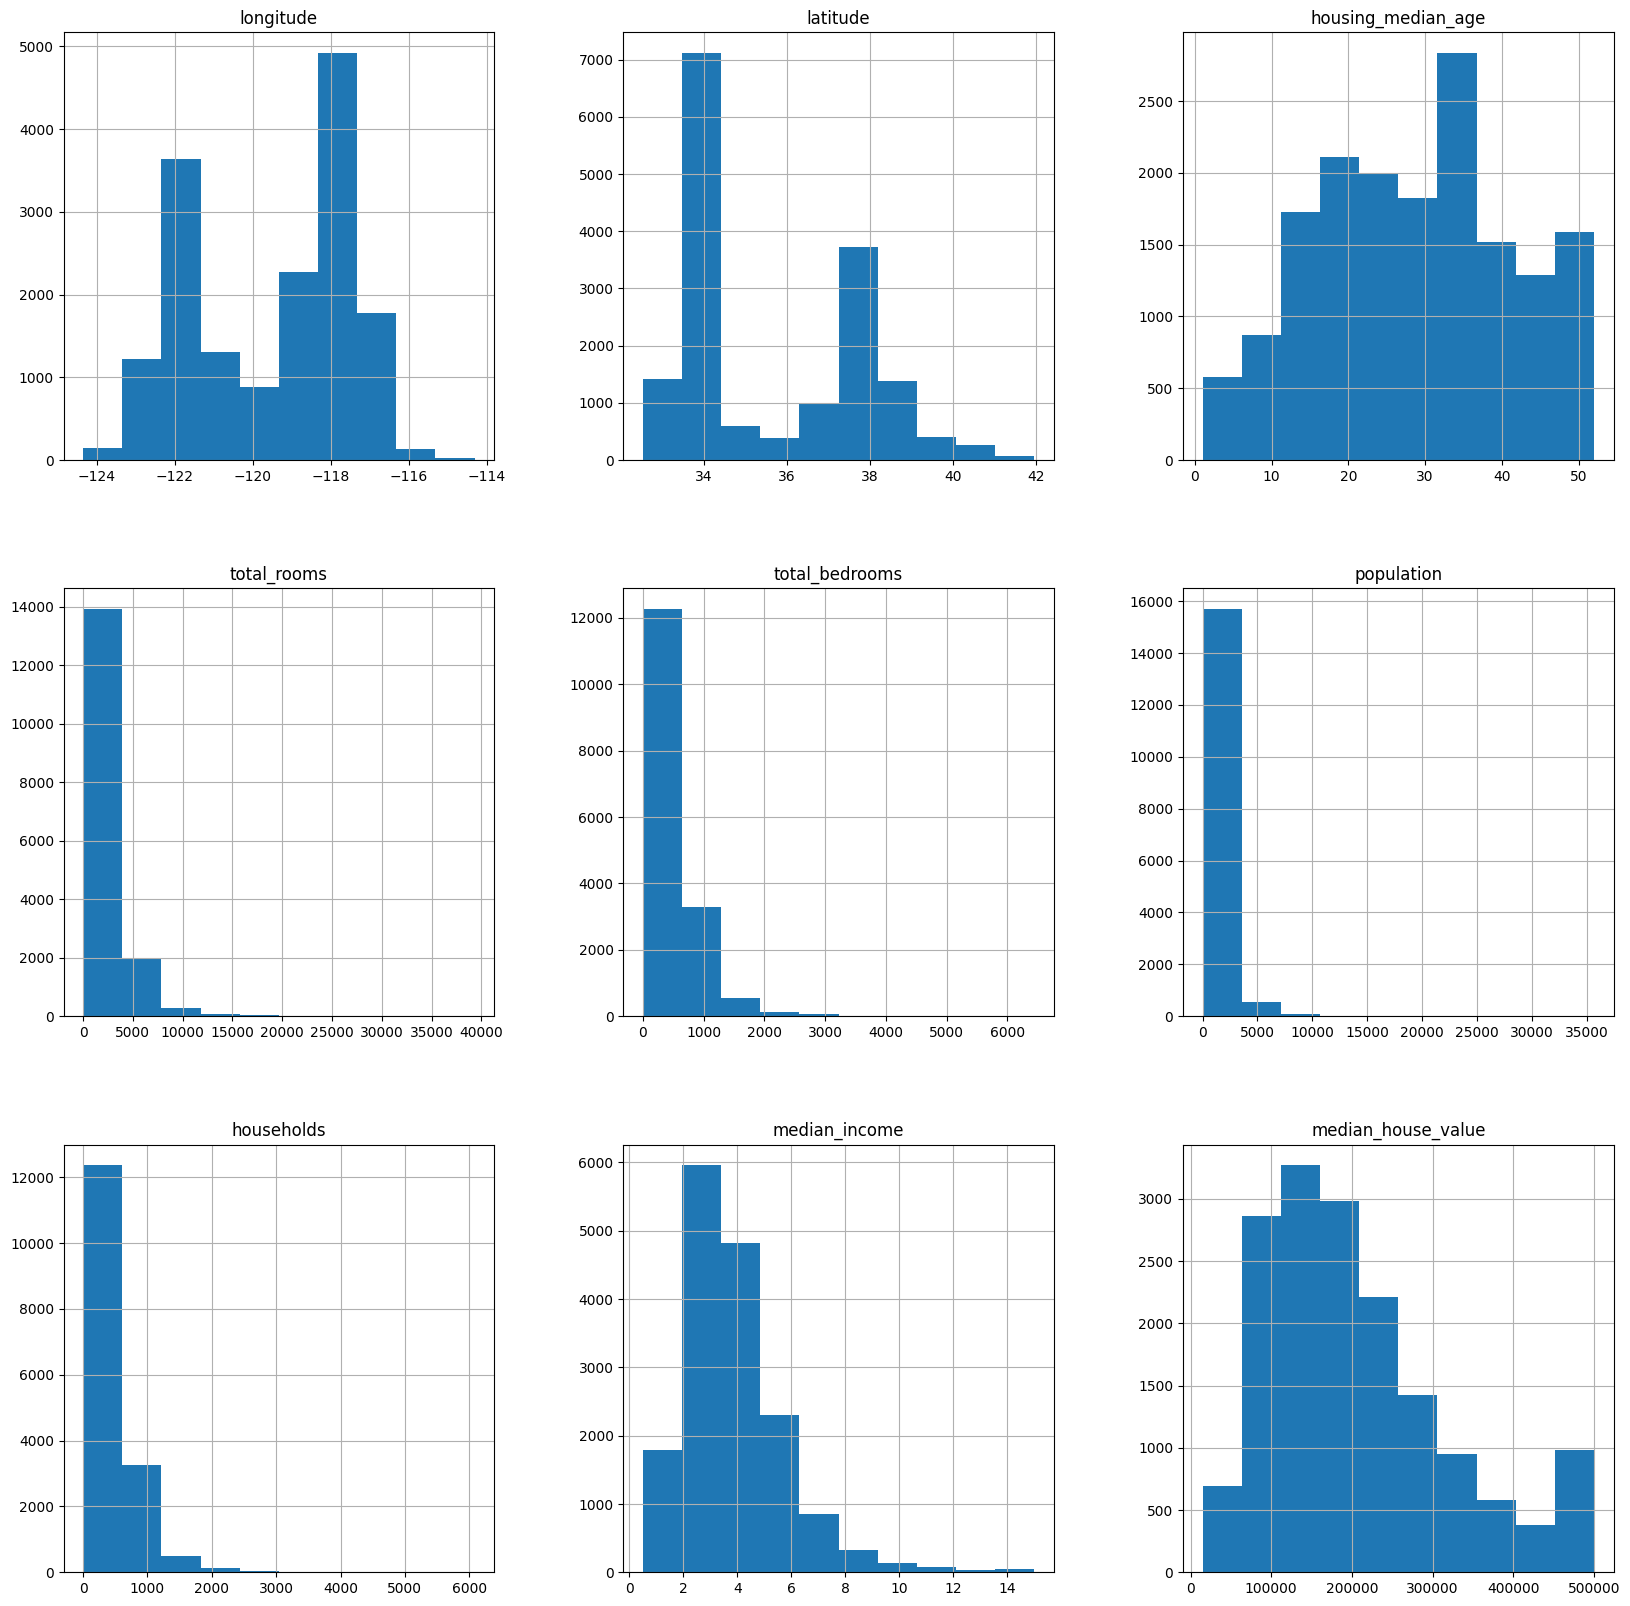

In [11]:
train_data.hist(figsize=(20, 20))

In [12]:
train_data.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.923623,-0.105557,0.041472,0.065263,0.096041,0.052653,-0.014306,-0.043687
latitude,-0.923623,1.000000,0.008937,-0.034038,-0.064372,-0.107325,-0.069802,-0.080188,-0.146749
housing_median_age,-0.105557,0.008937,1.000000,-0.360504,-0.320742,-0.292211,-0.302076,-0.119795,0.100068
total_rooms,0.041472,-0.034038,-0.360504,1.000000,0.930533,0.855653,0.918490,0.197241,0.133783
total_bedrooms,0.065263,-0.064372,-0.320742,0.930533,1.000000,0.876092,0.979412,-0.006818,0.052889
population,0.096041,-0.107325,-0.292211,0.855653,0.876092,1.000000,0.906077,0.002310,-0.022444
households,0.052653,-0.069802,-0.302076,0.918490,0.979412,0.906077,1.000000,0.013876,0.068597
median_income,-0.014306,-0.080188,-0.119795,0.197241,-0.006818,0.002310,0.013876,1.000000,0.689443
median_house_value,-0.043687,-0.146749,0.100068,0.133783,0.052889,-0.022444,0.068597,0.689443,1.000000


<Axes: >

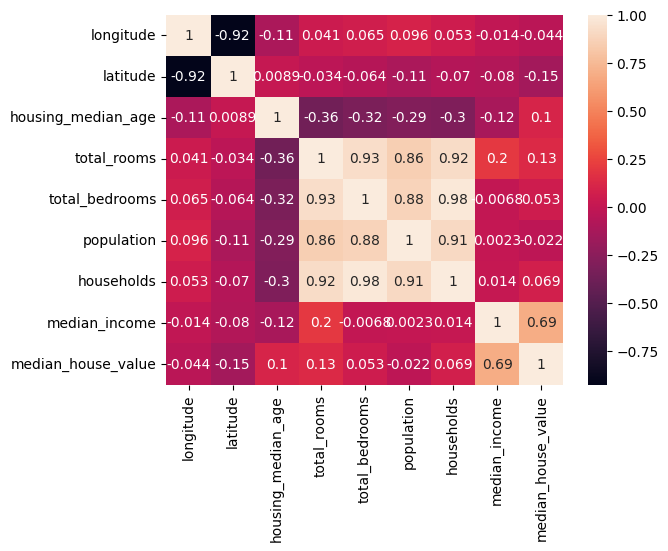

In [13]:
sns.heatmap(train_data.corr(numeric_only=True), annot=True)

In [14]:
train_data["total_rooms"] = np.log(train_data["total_rooms"] + 1)
train_data["total_bedrooms"] = np.log(train_data["total_bedrooms"] + 1)
train_data["population"] = np.log(train_data["population"] + 1)
train_data["households"] = np.log(train_data["households"] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

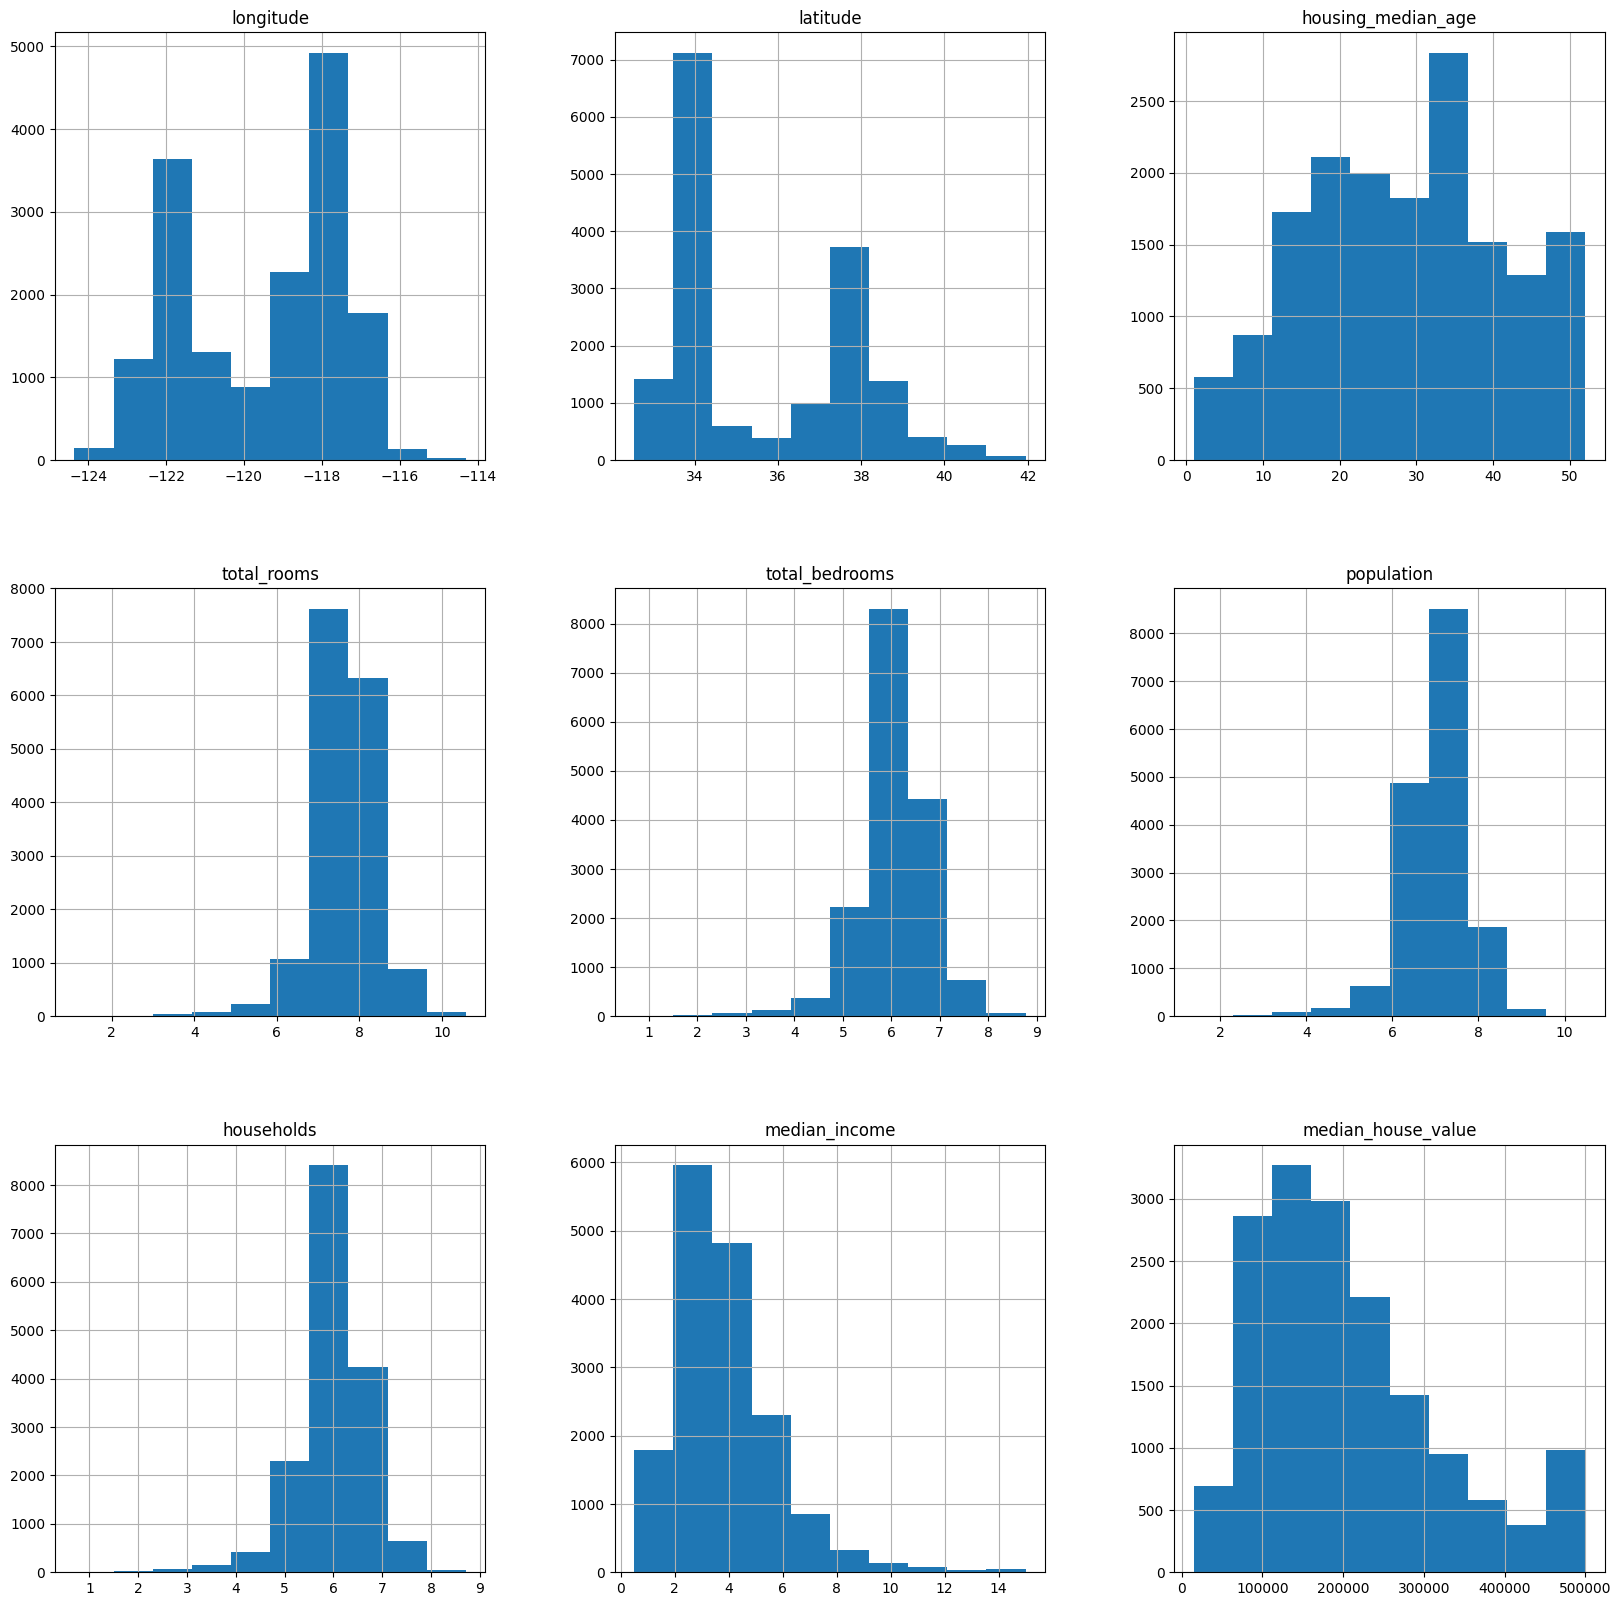

In [15]:
train_data.hist(figsize=(20, 20))

<Axes: >

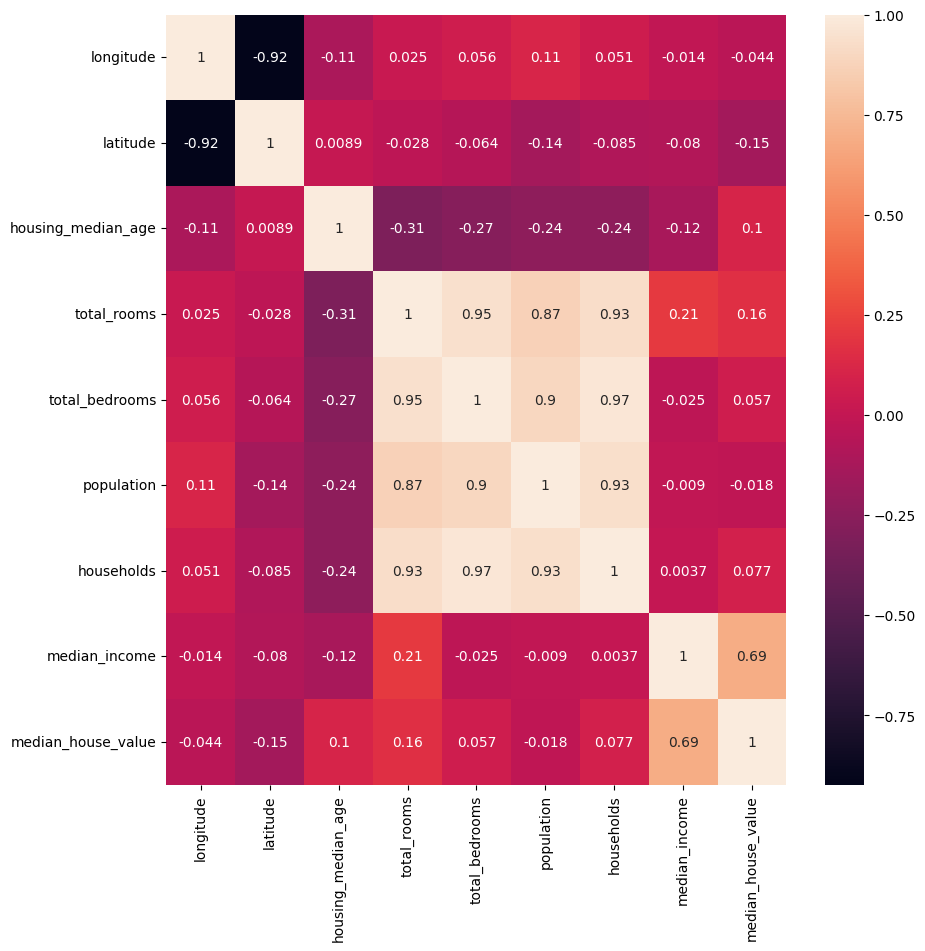

In [16]:
plt.figure(figsize=(10, 10))
sns.heatmap(train_data.corr(numeric_only=True), annot=True)

In [17]:
train_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     7230
INLAND        5167
NEAR OCEAN    2139
NEAR BAY      1805
ISLAND           5
Name: count, dtype: int64

In [18]:
if "ocean_proximity" in train_data.columns:
    train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity)).drop(["ocean_proximity"], axis=1)
train_data


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
6021,-117.76,34.06,30.0,7.438972,6.224558,7.450080,6.131226,2.2270,91900.0,False,True,False,False,False
19922,-119.35,36.32,10.0,8.247482,6.579251,7.430707,6.572283,3.8235,94600.0,False,True,False,False,False
16878,-122.39,37.60,44.0,7.742836,5.953243,6.894670,5.940171,4.6520,387100.0,False,False,False,False,True
2928,-119.01,35.37,33.0,6.711740,5.204007,6.363028,5.153292,1.2469,46700.0,False,True,False,False,False
8370,-118.34,33.98,40.0,7.653969,6.267201,7.561642,6.300786,3.1630,137800.0,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12124,-117.24,33.94,15.0,7.358831,6.049733,7.024649,5.913503,1.6111,113900.0,False,True,False,False,False
18620,-122.03,37.00,30.0,7.639161,5.837730,6.705639,5.796058,5.2078,440500.0,False,False,False,False,True
15926,-122.44,37.73,52.0,6.765039,5.327876,6.376727,5.147494,5.0224,261900.0,False,False,False,True,False
17366,-120.43,34.95,43.0,7.611348,5.843544,6.541030,5.739793,3.6815,181800.0,True,False,False,False,False


<Axes: >

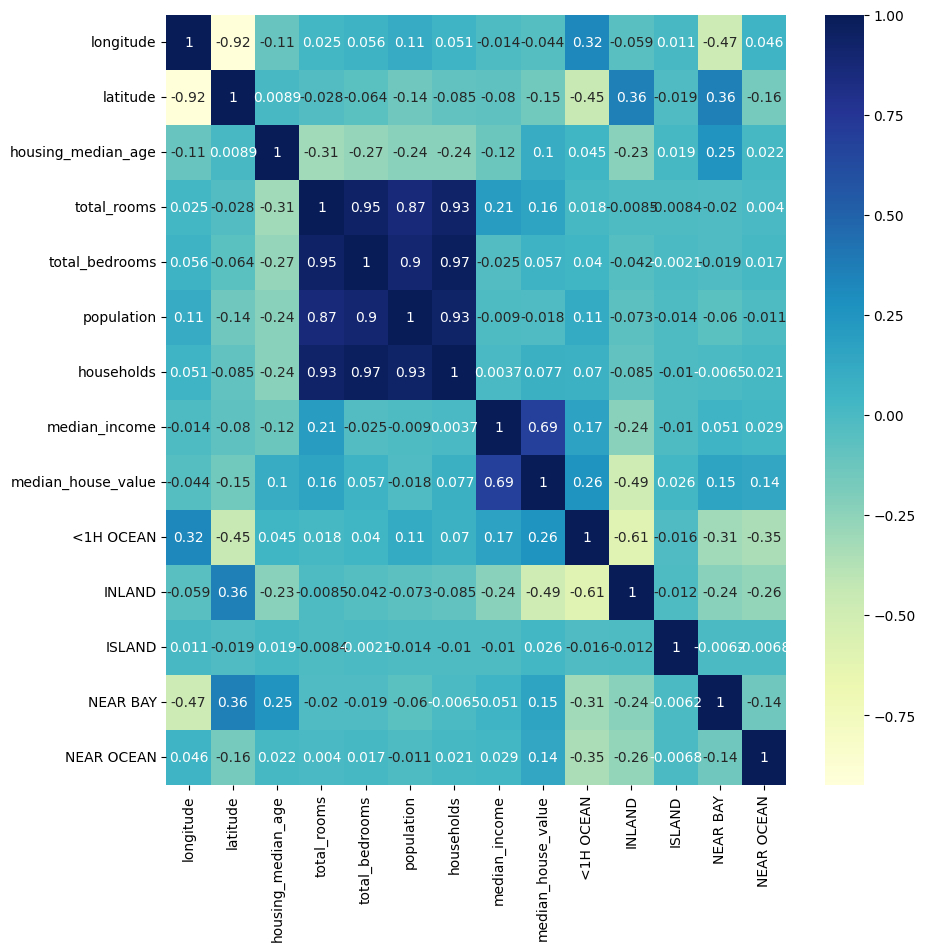

In [19]:
plt.figure(figsize=(10, 10))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

In [20]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
6021,-117.76,34.06,30.0,7.438972,6.224558,7.450080,6.131226,2.2270,91900.0,False,True,False,False,False
19922,-119.35,36.32,10.0,8.247482,6.579251,7.430707,6.572283,3.8235,94600.0,False,True,False,False,False
16878,-122.39,37.60,44.0,7.742836,5.953243,6.894670,5.940171,4.6520,387100.0,False,False,False,False,True
2928,-119.01,35.37,33.0,6.711740,5.204007,6.363028,5.153292,1.2469,46700.0,False,True,False,False,False
8370,-118.34,33.98,40.0,7.653969,6.267201,7.561642,6.300786,3.1630,137800.0,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12124,-117.24,33.94,15.0,7.358831,6.049733,7.024649,5.913503,1.6111,113900.0,False,True,False,False,False
18620,-122.03,37.00,30.0,7.639161,5.837730,6.705639,5.796058,5.2078,440500.0,False,False,False,False,True
15926,-122.44,37.73,52.0,6.765039,5.327876,6.376727,5.147494,5.0224,261900.0,False,False,False,True,False
17366,-120.43,34.95,43.0,7.611348,5.843544,6.541030,5.739793,3.6815,181800.0,True,False,False,False,False


<Axes: xlabel='latitude', ylabel='longitude'>

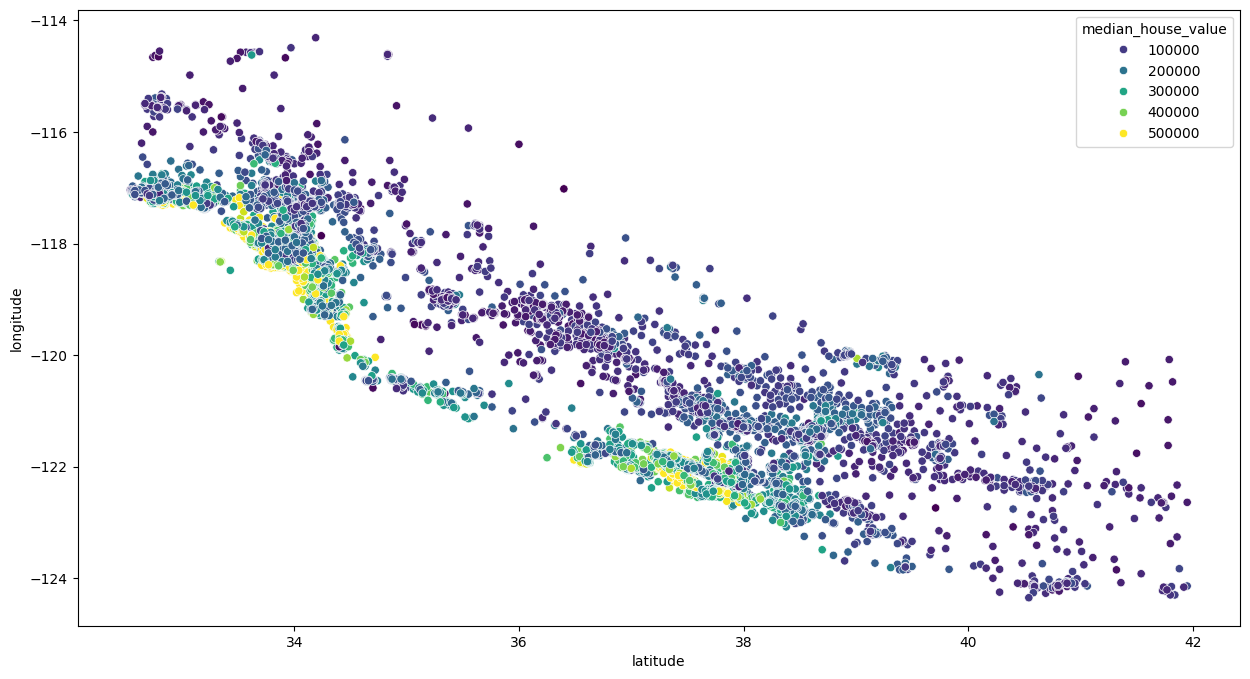

In [21]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette="viridis")

In [22]:
# Feature engineering
train_data["bedroom_ratio"] = train_data["total_bedrooms"] / train_data["total_rooms"]
train_data["household_rooms"] = train_data["total_rooms"] / train_data["households"]

<Axes: >

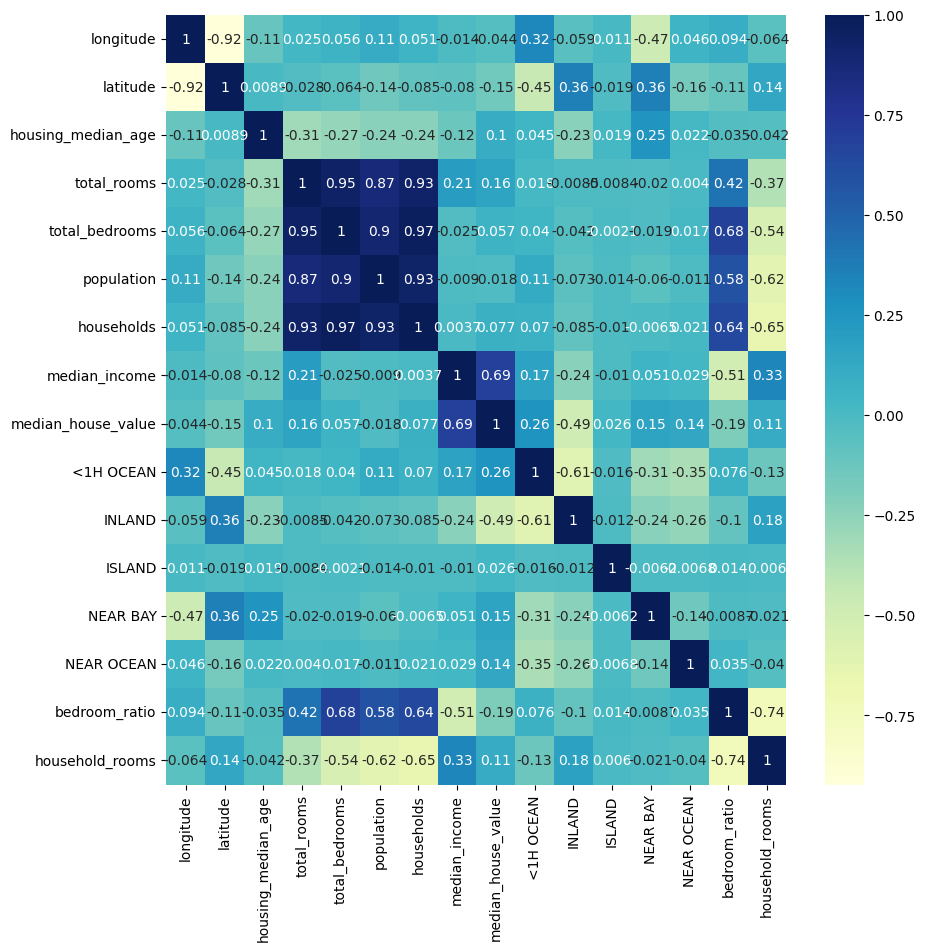

In [23]:
plt.figure(figsize=(10, 10))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")


In [24]:
# Creating Models
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()

X_train, Y_train = train_data.drop(["median_house_value"], axis=1), train_data["median_house_value"]
x_train_s = scalar.fit_transform(X_train)

reg = LinearRegression()
reg.fit(x_train_s, Y_train)    

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
test_data = x_test.join(y_test)

test_data["total_rooms"] = np.log(test_data["total_rooms"] + 1)
test_data["total_bedrooms"] = np.log(test_data["total_bedrooms"] + 1)
test_data["population"] = np.log(test_data["population"] + 1)
test_data["households"] = np.log(test_data["households"] + 1)

if "ocean_proximity" in test_data.columns:
    test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity)).drop(["ocean_proximity"], axis=1)
    
test_data["bedroom_ratio"] = test_data["total_bedrooms"] / test_data["total_rooms"]
test_data["household_rooms"] = test_data["total_rooms"] / test_data["households"]

In [26]:
x_test, y_test = test_data.drop(["median_house_value"], axis=1), test_data["median_house_value"]

In [27]:
text_code_s = scalar.transform(x_test)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- ISLAND


In [ ]:
reg.score(text_code_s, y_test)

NameError: name 'reg' is not defined